In [ ]:
print("hello")

In [1]:
# Core data libraries
import os
import pickle
import warnings
from pathlib import Path

import joblib
import numpy as np 
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and modeling tools
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Resolve paths from the notebook folder to the project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebook" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "predictive_maintenance.csv"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(df.info())

Rows: 10,000
Columns: 10
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB
None


In [7]:
print(f"duplicate rows: {df.duplicated().sum():,}")

duplicate rows: 0


In [17]:
#Target distribution. Predictive maintenance data is usually imbalanced beacause failures are rare events. 
target_counts = df["Target"].value_counts().rename(index={0: "No Failure", 1: "Failure"})
target_pct = df["Target"].value_counts(normalize=True).mul(100).round(2).rename(index={0: "No Failure", 1: "Failure"})
pd.DataFrame({"Count": target_counts, "Percentage": target_pct})

,Count,Percentage
Target,,
No Failure,9661,96.61
Failure,339,3.39


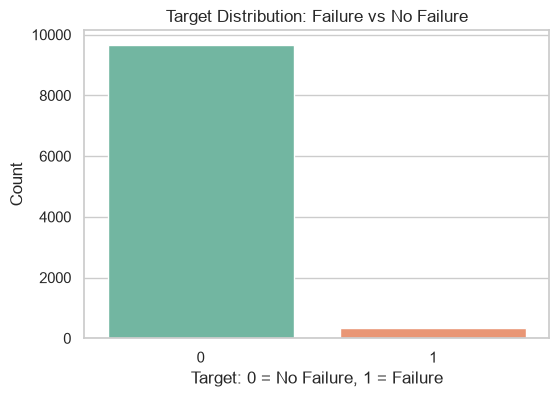

In [18]:
#Visualise class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x="Target", data=df, palette="Set2")
plt.title("Target Distribution: Failure vs No Failure")
plt.xlabel("Target: 0 = No Failure, 1 = Failure")
plt.ylabel("Count")
plt.show()

In [20]:
df["Failure Type"].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [22]:
df["Type"].value_counts(normalize=True).mul(100).round(2)

Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64

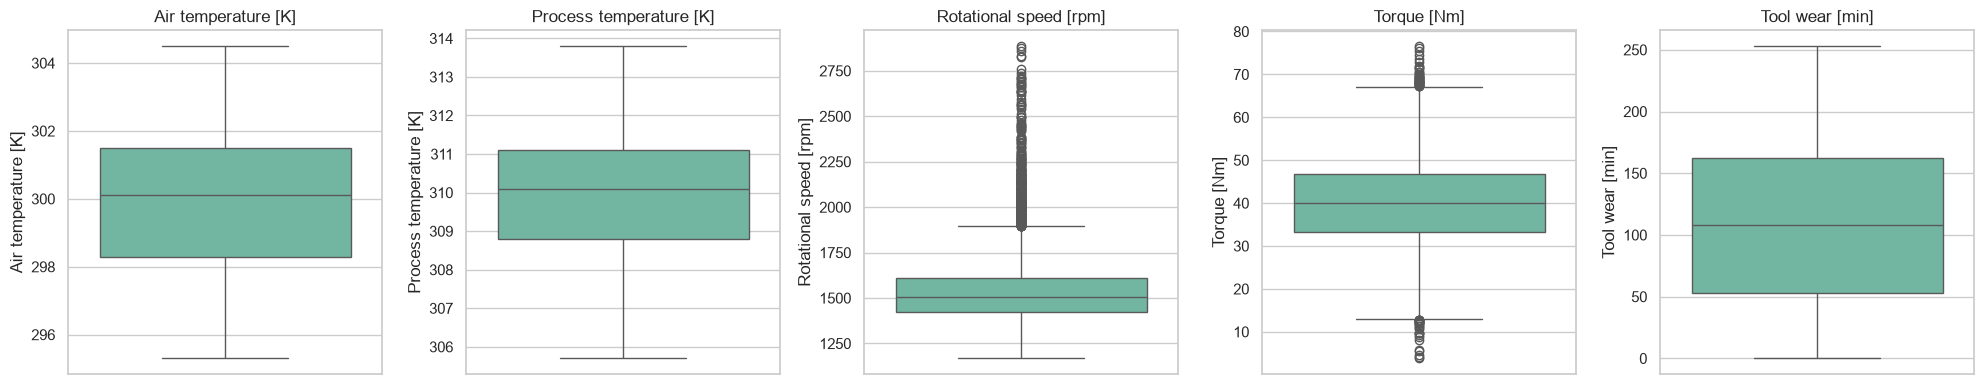

In [23]:
numeric_features_for_eda = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

fig, axes = plt.subplots(1, len(numeric_features_for_eda), figsize=(20, 4))
for ax, col in zip(axes, numeric_features_for_eda):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"{col}")
plt.tight_layout()
plt.show()

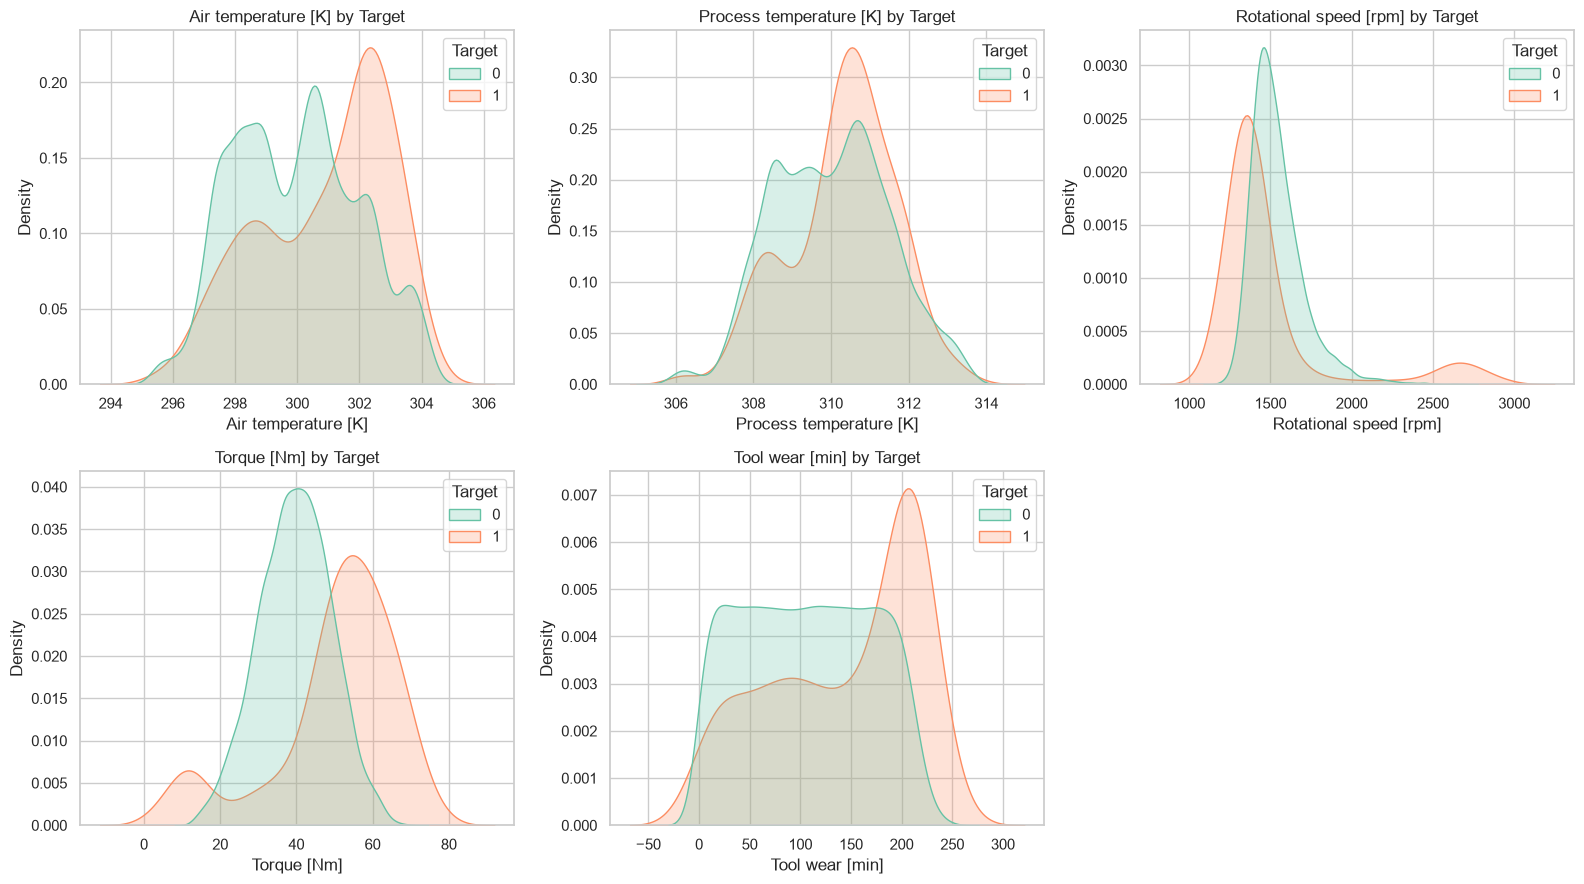

In [25]:
#Compare numerical feature distributions against the failure label.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, numeric_features_for_eda):
    sns.kdeplot( data=df,x=col, hue="Target", common_norm=False, fill=True, ax=ax)
    ax.set_title(f"{col} by Target")
axes[-1].axis("off")  # Turn off the last empty subplot
plt.tight_layout()
plt.show()

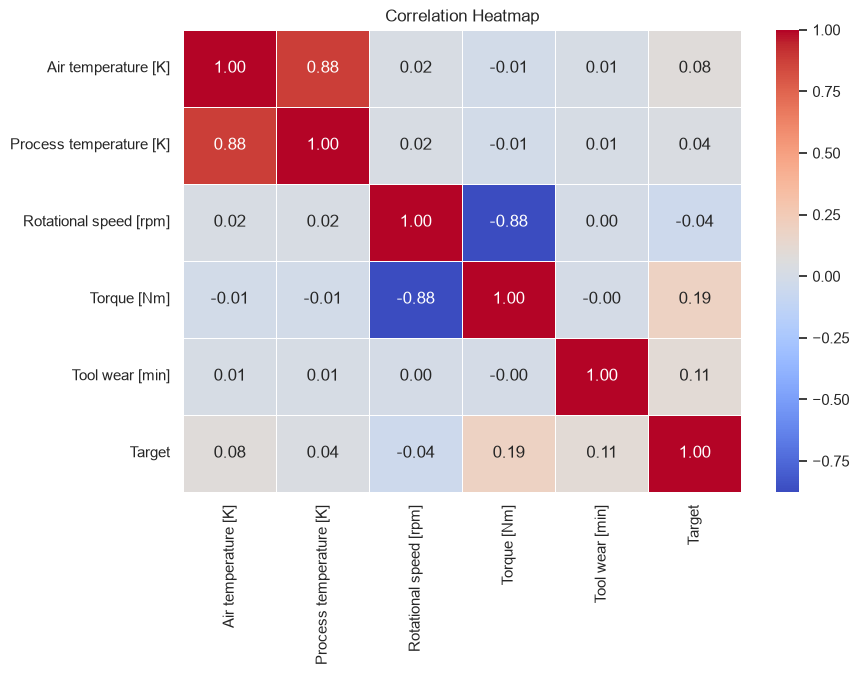

In [26]:
#Correlation heatmap to visualize relationships between numerical features and the target variable.
corr_cols = numeric_features_for_eda + ["Target"]
plt.figure(figsize=(9, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
target = "Target"
drop_cols = ["UDI", "Product ID", "Failure Type",target]

x = df.drop(columns=drop_cols)
y = df[target]

numeric_features = x.select_dtypes(include=["float64", "int64"]).columns.tolist()
categorical_features = x.select_dtypes(include=["object","category"]).columns.tolist()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Categorical features: ['Type']


In [33]:
#Preprocessing pipeline:
# - Median imputation is robust to outliers for numeric columns.
# - Most- frequent implies missingutation hand categorical values.
# - OneHotEncoder converts type into machine-readable bary indicators.
# - StandardScaler standardizes numeric features for Logistic Regression.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)   


In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Train target distribution:
Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Test target distribution:
Target
0    0.966
1    0.034
Name: proportion, dtype: float64


In [39]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
])

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])

log_reg_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
}

dt_params = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 10, 25],
    "model__min_samples_leaf": [1, 5, 10],
    "model__criterion": ["gini", "entropy"],
}

model_configs = {
    "Logistic Regression": {
        "pipeline": log_reg_pipeline,
        "params": log_reg_params,
    },
    "Decision Tree": {
        "pipeline": dt_pipeline,
        "params": dt_params,
    },
}

In [41]:
def simple_hyperparameter_tuning(model_name, pipeline, param_grid, x_train, y_train):
    """Simple validation-based tuning without GridSearchCV or cross-validation."""
    # Create a validation split from the training data only.
    # The test data is still untouched and will be used only for final evaluation.
    X_fit, X_valid, y_fit, y_valid = train_test_split(
        x_train,
        y_train,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )

    best_score = -np.inf
    best_params = None
    tuning_results = []

    for params in ParameterGrid(param_grid):
        # Clone gives a fresh unfitted pipeline for every parameter combination.
        candidate_model = clone(pipeline)
        candidate_model.set_params(**params)
        candidate_model.fit(X_fit, y_fit)

        y_valid_pred = candidate_model.predict(X_valid)
        valid_f1 = f1_score(y_valid, y_valid_pred, zero_division=0)

        tuning_results.append({"params": params, "validation_f1": valid_f1})

        if valid_f1 > best_score:
            best_score = valid_f1
            best_params = params

    # Refit the winning configuration on the full training data.
    best_estimator = clone(pipeline)
    best_estimator.set_params(**best_params)
    best_estimator.fit(x_train, y_train)

    return {
        "model_name": model_name,
        "best_estimator": best_estimator,
        "best_params": best_params,
        "best_score": best_score,
        "tuning_results": pd.DataFrame(tuning_results).sort_values("validation_f1", ascending=False),
    }


model_searches = {}
for model_name, config in model_configs.items():
    print(f"\nTraining {model_name}...")
    search_result = simple_hyperparameter_tuning(
        model_name=model_name,
        pipeline=config["pipeline"],
        param_grid=config["params"],
        x_train=x_train,
        y_train=y_train,
    )
    model_searches[model_name] = search_result
    print(f"Best validation F1: {search_result['best_score']:.4f}")
    print(f"Best params: {search_result['best_params']}")


Training Logistic Regression...
Best validation F1: 0.2466
Best params: {'model__C': 0.1, 'model__solver': 'lbfgs'}

Training Decision Tree...
Best validation F1: 0.6337
Best params: {'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}



Logistic Regression Classification Report
              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.90      1932
     Failure       0.14      0.81      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



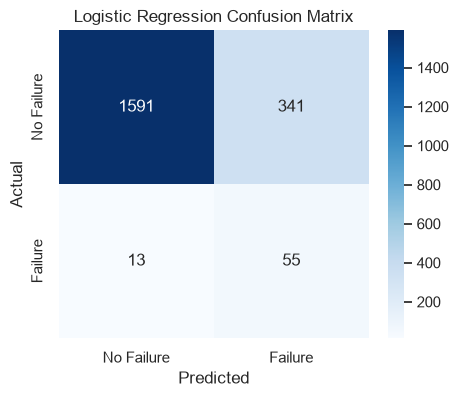


Decision Tree Classification Report
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.73      0.60      0.66        68

    accuracy                           0.98      2000
   macro avg       0.86      0.80      0.83      2000
weighted avg       0.98      0.98      0.98      2000



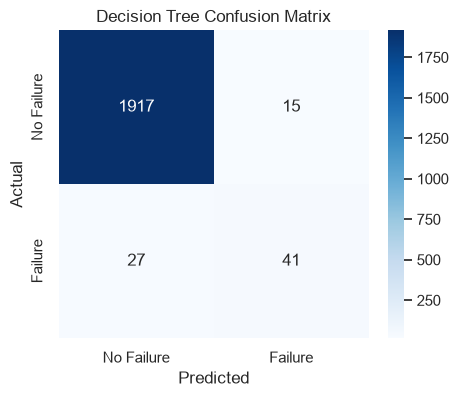

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.823,0.138889,0.808824,0.237069,0.906581
1,Decision Tree,0.979,0.732143,0.602941,0.661290,0.797589


In [43]:
def evaluate_model(name, estimator, x_test, y_test):
    """Evaluate a fitted classifier and return important metrics."""
    y_pred = estimator.predict(x_test)
    y_proba = estimator.predict_proba(x_test)[:, 1] if hasattr(estimator, "predict_proba") else None

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
    }

    print(f"\n{name} Classification Report")
    print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return metrics

results = []
for model_name, search in model_searches.items():
    results.append(evaluate_model(model_name, search["best_estimator"], x_test, y_test))

# For predictive maintenance, recall is often the most important metric
# because missing an actual failure can be more expensive than a false alarm.
results_df = pd.DataFrame(results).sort_values(by="recall", ascending=False)
results_df

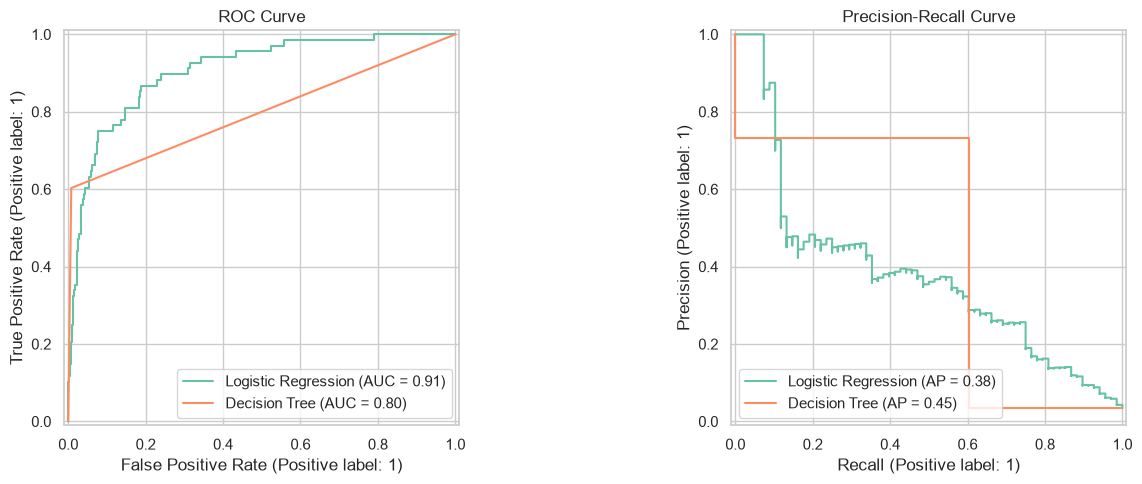

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, search in model_searches.items():
    RocCurveDisplay.from_estimator(search["best_estimator"], x_test, y_test, ax=axes[0], name=model_name)
    PrecisionRecallDisplay.from_estimator(search["best_estimator"], x_test, y_test, ax=axes[1], name=model_name)
axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [47]:
# Since this is predictive maintenance, select the model with the best Recall.
# If Logistic Regression has the highest recall in results_df, then it is fair to say it is best for this business objective.
best_model_name = results_df.iloc[0]["model"]
best_model = model_searches[best_model_name]["best_estimator"]

model_bundle = {
    "model_name": best_model_name,
    "model": best_model,
    "feature_columns": x.columns.tolist(),
    "selection_metric": "recall",
    "test_metrics": results_df.iloc[0].to_dict(),
}

model_path = MODEL_DIR / "predictive_maintenance_model.pkl"
with open(model_path, "wb") as file:
    pickle.dump(model_bundle, file)

print(f"Best model by Recall: {best_model_name}")
print(f"Saved pickle model to: {model_path}")

Best model by Recall: Logistic Regression
Saved pickle model to: /Users/deeraj/Library/Mobile Documents/com~apple~CloudDocs/AI Engineering/Class 2/Project/models/predictive_maintenance_model.pkl


In [49]:
# Quick load test to confirm the pickle artifact works.
with open(model_path, "rb") as file:
    loaded_bundle = pickle.load(file)

loaded_model = loaded_bundle["model"]
sample_predictions = loaded_model.predict(x_test.head())
print("Sample predictions:", sample_predictions)

Sample predictions: [1 1 1 0 1]
